This is a test script to try using automatic differentiation with Sionna's radio map solver

In [1]:
#All of the imports
import sionna.rt
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import math
import drjit as dr
import mitsuba as mi
from typing import Tuple, List
import random 

from sionna.rt import load_scene, PlanarArray, Transmitter, Receiver, Camera,\
                      PathSolver, RadioMapSolver, subcarrier_frequencies

from tabulate import tabulate

#Where all the constants RF harvesting functions, and custom display functions are stored
import radio_functions


using_preview = True

In [2]:
min_distance_between_points = 100
def distance_between(a, b):
    return math.sqrt(math.pow(b[1] - a[1], 2) + math.pow(b[2]-a[2], 2))

#returns true if the position isn't close to o
def check_position_valid(pos, positions_array):
    for other_pos in positions_array:
        if(distance_between(pos, other_pos) < min_distance_between_points):
            return False
    
    return True

In [3]:
current_scene = load_scene("Blender/UBC.xml")
current_scene.preview();

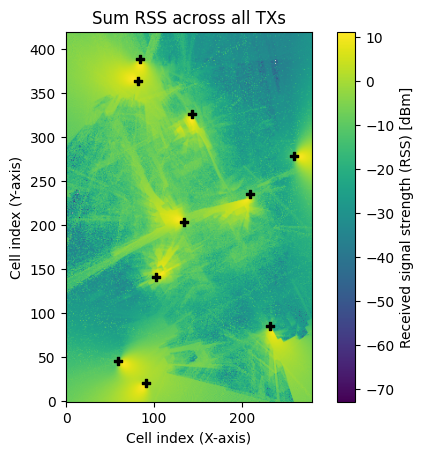

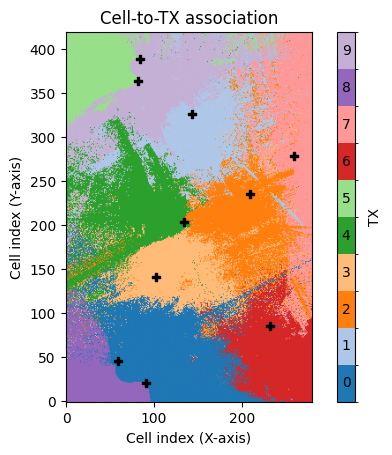

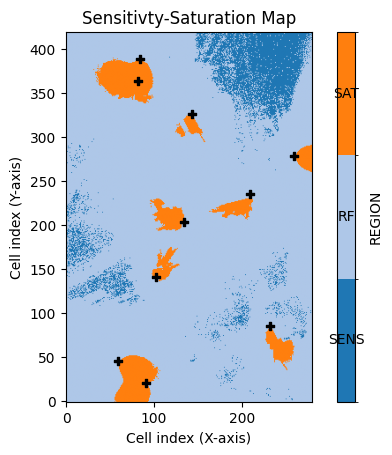

| Type   |   RX energy (dbm) |   DC energy (dbm) |   time (s) |
|--------+-------------------+-------------------+------------|
| Mean   |         -15.217   |        -18.643    |  11.8527   |
| Q1     |         -22.8584  |        -29.5669   | 146.624    |
| Median |         -14.0417  |        -16.4167   |   7.09888  |
| Q3     |          -7.32427 |         -0.303263 |   0.173774 |


| Not enough RF   | Charging   | Saturation   |
|-----------------+------------+--------------|
| 8.529%          | 85.236%    | 6.235%       |


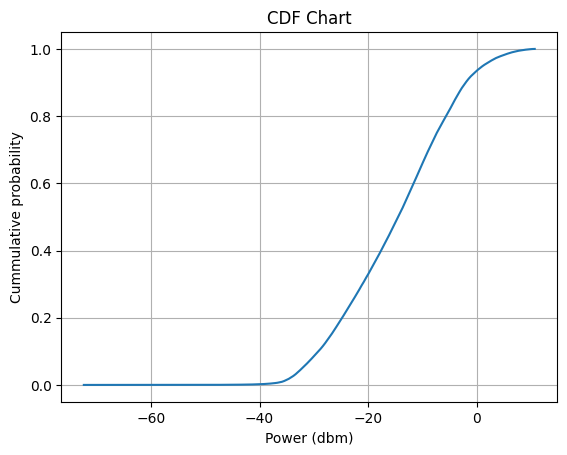

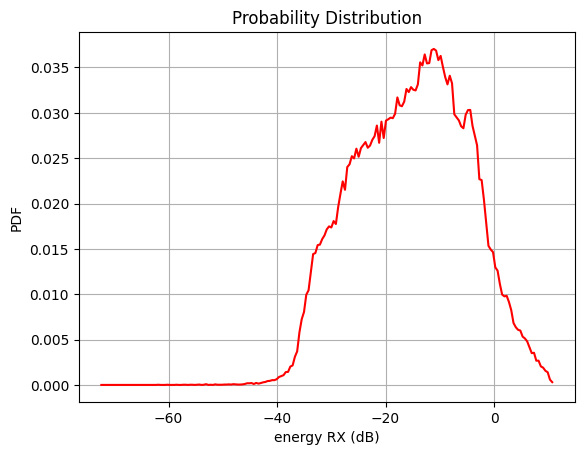

In [4]:
current_scene.frequency = 3e9
current_scene.tx_array = PlanarArray(num_rows=1,
                             num_cols=1, 
                             vertical_spacing=0.5,
                             horizontal_spacing=0.5,
                             pattern="tr38901",
                             polarization="V")

transmitters = []
positions_array = []

num_transmitters = 10
for i in range(num_transmitters):
    pos = [random.randint(-600, 600), random.randint(-1000, 1000), 25]
    num_iterations = 0
    while(not check_position_valid(pos, positions_array)):
        pos = [random.randint(-600, 600), random.randint(-1000, 1000), 25] 
        num_iterations += 1
        if(num_iterations > 100):
            print(f"to many iterations at transmitter #{i}")
            break
    
    positions_array.append(pos)
    transmitters.append(Transmitter(name=f"tx{i}", position=pos, display_radius=10, power_dbm=80))
    transmitters[-1].orientation = (random.random()*365.0, 0, 0) 
    current_scene.add(transmitters[-1])
    
rm_solver = RadioMapSolver()
rm = rm_solver(current_scene,
               max_depth=30,           # Maximum number of ray scene interactions
               samples_per_tx=10**7 , # If you increase: less noise, but more memory required
               cell_size=(5, 5),      # Resolution of the radio map
               center=[0, 10, 1],      # Center of the radio map
               size=[1400, 2100],       # Total size of the radio map
               orientation=[0, 0, 0]) # Orientation of the radio map, e.g., could be also vertical



radio_functions.show_sum(rm, metric="rss")
radio_functions.show_association_more_colours(rm)
radio_functions.show_DC_regions(rm, metric="rss")

cdf_values = radio_functions.sum_cdf(rm, metric="rss");
metrics = radio_functions.calculate_metrics_from_cdf(cdf_values)
metrics.print_related_values()
metrics.display_cdf_and_pdf(cdf_values[2])
current_scene.preview(radio_map=rm);

Sensitivity:


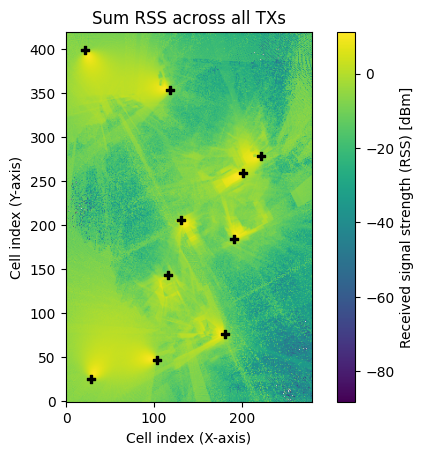

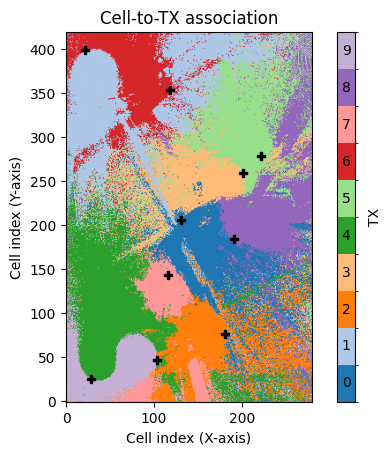

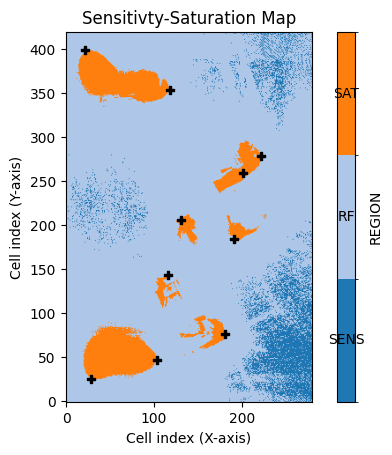

| Type   |   RX energy (dbm) |   DC energy (dbm) |   time (s) |
|--------+-------------------+-------------------+------------|
| Mean   |         -13.1149  |      -14.4178     |   4.4803   |
| Q1     |         -18.6491  |      -23.9447     |  40.178    |
| Median |         -10.7067  |       -7.89256    |   0.99724  |
| Q3     |          -5.24629 |       -0.00256717 |   0.162153 |


| Not enough RF   | Charging   | Saturation   |
|-----------------+------------+--------------|
| 7.958%          | 83.676%    | 8.366%       |



Saturation:


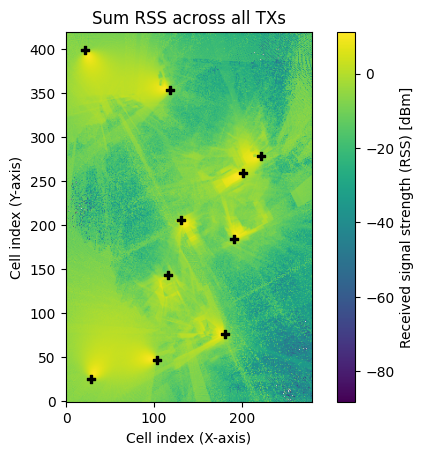

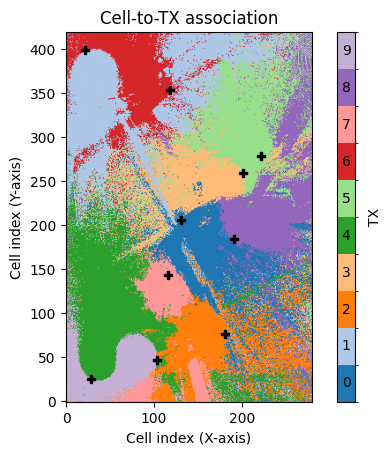

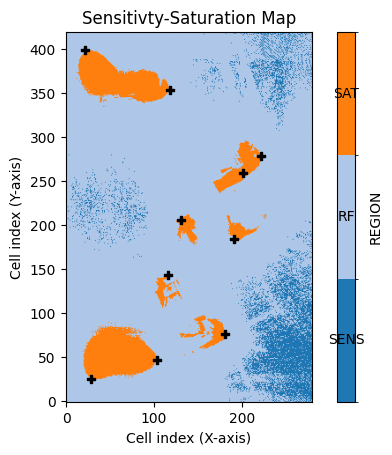

| Type   |   RX energy (dbm) |   DC energy (dbm) |   time (s) |
|--------+-------------------+-------------------+------------|
| Mean   |         -13.1149  |      -14.4178     |   4.4803   |
| Q1     |         -18.6491  |      -23.9447     |  40.178    |
| Median |         -10.7067  |       -7.89256    |   0.99724  |
| Q3     |          -5.24629 |       -0.00256717 |   0.162153 |


| Not enough RF   | Charging   | Saturation   |
|-----------------+------------+--------------|
| 7.958%          | 83.676%    | 8.366%       |


In [5]:
#Using the scene from above we run 10 tests to find the best positions we can find
num_simulations = 3
min_sensitivity_percentage = 1
min_saturation_percentage = 1
best_sens_radio_map = rm
best_sat_radio_map = rm
best_positions = []
best_orientations = []

for i in range(num_simulations):
    positions_array = []

    for j in range(num_transmitters):
        pos = [random.randint(-600, 600), random.randint(-1000, 1000), 25]
        num_iterations = 0
        while(not check_position_valid(pos, positions_array)):
            pos = [random.randint(-600, 600), random.randint(-1000, 1000), 25] 
            num_iterations += 1
            if(num_iterations > 100):
                print(f"to many placing iterations at transmitter #{i}")
                break
        
        positions_array.append(pos)
        transmitters[j].position = pos
        transmitters[j].orientation = (random.random()*365.0, 0, 0) 

    rm = rm_solver(current_scene,
        max_depth=30,           # Maximum number of ray scene interactions
        samples_per_tx=10**7 , # If you increase: less noise, but more memory required
        cell_size=(5, 5),      # Resolution of the radio map
        center=[0, 10, 1],      # Center of the radio map
        size=[1400, 2100],       # Total size of the radio map
        orientation=[0, 0, 0]) # Orientation of the radio map, e.g., could be also vertical

    cdf_values = radio_functions.sum_cdf(rm, metric="rss");
    metrics = radio_functions.calculate_metrics_from_cdf(cdf_values);
    #print(f"sens percentage is {metrics.sens_percentage*100:.3f}%")
    if(metrics.sens_percentage < min_sensitivity_percentage):
        min_sensitivity_percentage = metrics.sens_percentage
        best_sens_radio_map = rm
        best_positions = positions_array.copy()
        best_orientations = []
        for k in range(len(transmitters)):
            best_orientations.append(transmitters[k].orientation)


    if(metrics.sat_percentage < min_saturation_percentage):
        min_saturation_percentage = metrics.sat_percentage
        best_sat_radio_map = rm

    
print("Sensitivity:")
radio_functions.show_sum(best_sens_radio_map, metric="rss")
radio_functions.show_association_more_colours(best_sens_radio_map)
radio_functions.show_DC_regions(best_sens_radio_map, metric="rss")

cdf_values = radio_functions.sum_cdf(best_sens_radio_map, metric="rss")
metrics = radio_functions.calculate_metrics_from_cdf(cdf_values)
metrics.print_related_values()

print("\n\n\nSaturation:")
radio_functions.show_sum(best_sat_radio_map, metric="rss")
radio_functions.show_association_more_colours(best_sat_radio_map)
radio_functions.show_DC_regions(best_sat_radio_map, metric="rss")

cdf_values = radio_functions.sum_cdf(best_sat_radio_map, metric="rss")
metrics = radio_functions.calculate_metrics_from_cdf(cdf_values)
metrics.print_related_values()

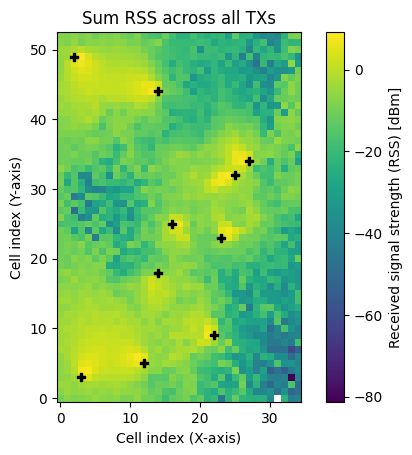

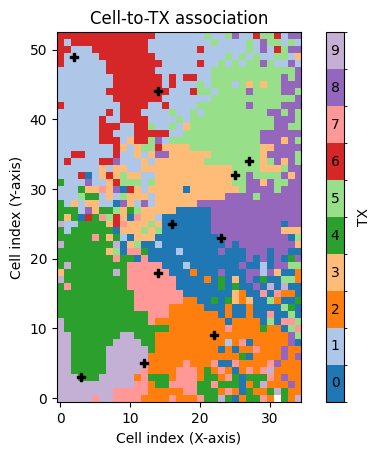

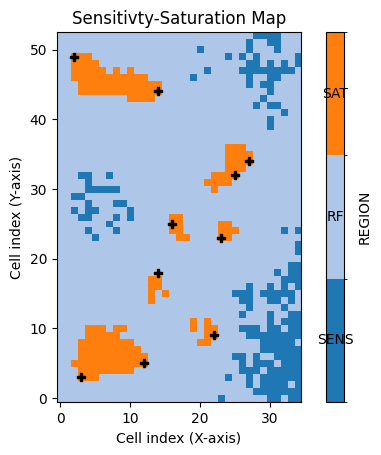

| Type   |   RX energy (dbm) |   DC energy (dbm) |   time (s) |
|--------+-------------------+-------------------+------------|
| Mean   |         -13.395   |     -15.0481      |   5.18006  |
| Q1     |         -19.7711  |     -25.4716      |  57.1052   |
| Median |         -10.7358  |      -7.98256     |   1.01812  |
| Q3     |          -4.86279 |      -0.000799453 |   0.162087 |


| Not enough RF   | Charging   | Saturation   |
|-----------------+------------+--------------|
| 9.978%          | 81.284%    | 8.738%       |
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0


In [6]:
for i in range(len(best_orientations)):
    transmitters[i].position = best_positions[i]
    dr.enable_grad(best_orientations[i])
    transmitters[i].orientation = mi.Point3f(best_orientations[i])

#a = dr.zeros(mi.Vector4f, 1)
#a.enable_grad()
rm_solver.loop_mode = "evaluated"
rm = rm_solver(current_scene,
        max_depth=30,           # Maximum number of ray scene interactions
        samples_per_tx=10**5 , # If you increase: less noise, but more memory required
        cell_size=(40, 40),      # Resolution of the radio map
        center=[0, 10, 1],      # Center of the radio map
        size=[1400, 2100],       # Total size of the radio map
        orientation=[0, 0, 0]) # Orientation of the radio map, e.g., could be also vertical

#dr.enable_grad(transmitters[0].orientation)


radio_functions.show_sum(rm, metric="rss")
radio_functions.show_association_more_colours(rm)
radio_functions.show_DC_regions(rm, metric="rss")

cdf_values = radio_functions.sum_cdf(rm, metric="rss")
metrics = radio_functions.calculate_metrics_from_cdf(cdf_values)
metrics.print_related_values()

for i in range(len(radio_functions.sum_radio_map(rm, metric="rss"))):
    for j in range(len(radio_functions.sum_radio_map(rm, metric="rss")[i])):
        a = radio_functions.sum_radio_map(rm, metric="rss")[i][j]
        dr.backward(a)
        print(a.grad)